TELCO CUSTOMER CHURN
Exploratory data analysis

The objectives of this analysis are:
1) to identify customer characteristics and service patterns associated with churn
2) understand the major drivers of customer attrition
3) identify customer segments that may benefit from targeted retention strategies.

## 1. Setup

This cleaned customer dataset is loaded for exploratoy analysis.
The analysis uses Pandas for data manipulation and Matplotlib/Seaborn for visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
telco_churn_df = pd.read_csv("../../1_data/2_processed/telco_churn_clean.csv")

In [3]:
telco_churn_df.shape

(7043, 21)

In [4]:
telco_churn_df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
telco_churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   str    
 1   gender             7043 non-null   str    
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   str    
 4   dependents         7043 non-null   str    
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   str    
 7   multiple_lines     7043 non-null   str    
 8   internet_service   7043 non-null   str    
 9   online_security    7043 non-null   str    
 10  online_backup      7043 non-null   str    
 11  device_protection  7043 non-null   str    
 12  tech_support       7043 non-null   str    
 13  streaming_tv       7043 non-null   str    
 14  streaming_movies   7043 non-null   str    
 15  contract           7043 non-null   str    
 16  paperless_billing  7043 non-null   

In [6]:
telco_churn_df.describe()

,senior_citizen,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Dataset overview

The dataset contains 7,043 customer records. Each row represents one customer and includes demographic information, subscribed services, contract details, billing information, and churn status.

### Variable groups

**Customer characteristics:**
- gender
- senior_citizen
- partner
- dependents

**Customer relationship and account:**
- tenure
- contract
- paperless_billing
- payment_method

**Services:**
- phone_service
- multiple_lines
- internet_service
- online_security
- online_backup
- device_protection
- tech_support
- streaming_tv
- streaming_movies

**Financial:**
- monthly_ charges
- total_charges

Target variable: churn

## 2. Overall churn

In [7]:
telco_churn_df["churn"].value_counts(normalize=True)

churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [8]:
churn_rate = (
    telco_churn_df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

churn_rate

churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

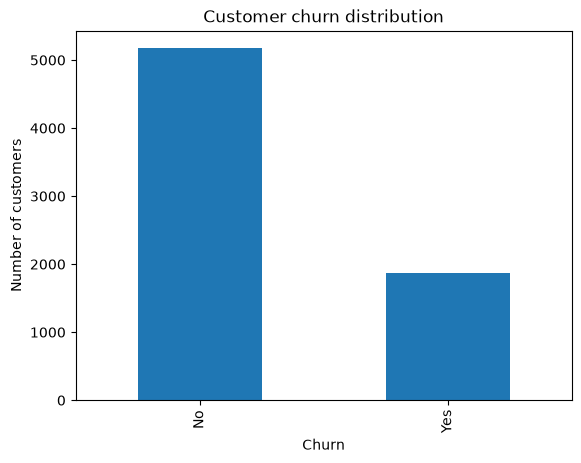

In [9]:
#overall churn rate
telco_churn_df["churn"].value_counts().plot(kind="bar")
plt.title("Customer churn distribution")
plt.xlabel("Churn")
plt.ylabel("Number of customers")
plt.show()

Approximately 27% of customers churned while 73% remained. 

## 3. Numerical variables
### 3.1 Tenure

In [10]:
telco_churn_df.groupby("churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


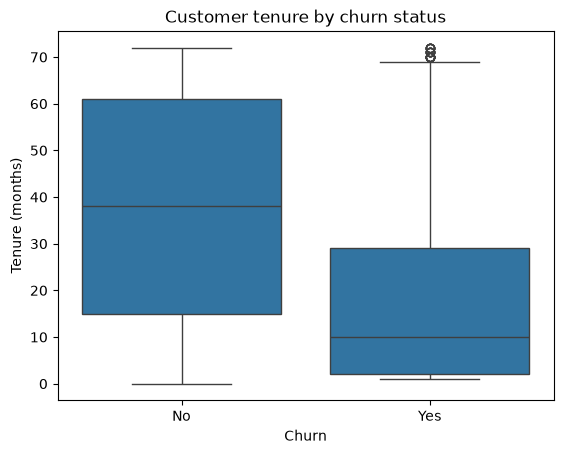

In [11]:
sns.boxplot(
    data=telco_churn_df,
    x="churn",
    y="tenure"

)

plt.title("Customer tenure by churn status")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

Customers who churn tend to have shorter tenure than customers who remain with the company.

### 3.2 Monthly charges

In [12]:
telco_churn_df.groupby("churn")["monthly_charges"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


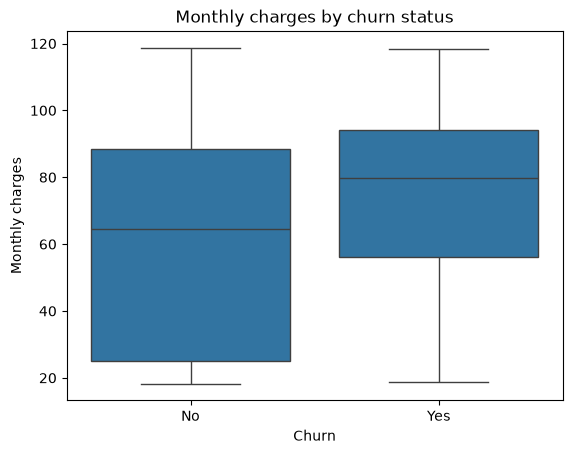

In [13]:
sns.boxplot(
    data=telco_churn_df,
    x="churn",
    y="monthly_charges"
)

plt.title("Monthly charges by churn status")
plt.xlabel("Churn")
plt.ylabel("Monthly charges")
plt.show()

Higher monthly charges may be associated with increased churn risk.

### 3.3 Total charges

In [14]:
telco_churn_df.groupby("churn")["total_charges"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


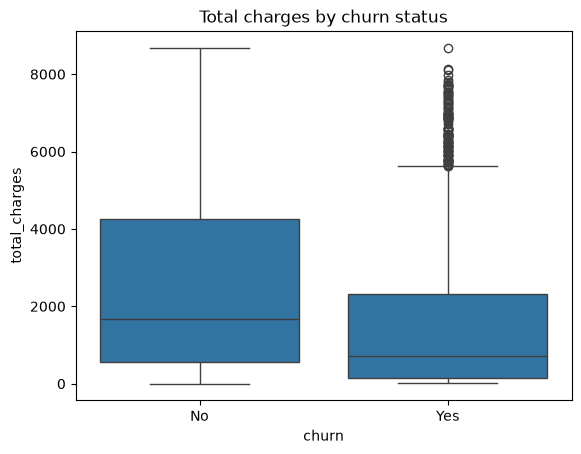

In [15]:
sns.boxplot(
    data=telco_churn_df,
    x="churn",
    y="total_charges"
)

plt.title("Total charges by churn status")
plt.show()

Lower total charges may partly reflect shorter tenure.

In [16]:
numeric_corr = telco_churn_df[
    [
    "senior_citizen",
    "tenure",
    "monthly_charges",
    "total_charges"
    ]
].corr()

numeric_corr

,senior_citizen,tenure,monthly_charges,total_charges
senior_citizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
monthly_charges,0.220173,0.247900,1.000000,0.651174
total_charges,0.103006,0.826178,0.651174,1.000000


## 4. Customer characteristics 
### 4.1 Gender

In [17]:
pd.crosstab(
    telco_churn_df["gender"],
    telco_churn_df["churn"],
    normalize="index"
) * 100

churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


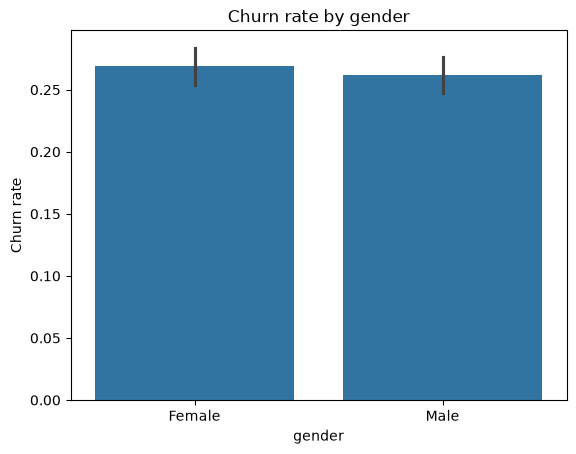

In [18]:
sns.barplot(
    data=telco_churn_df,
    x="gender",
    y=telco_churn_df["churn"].map({"Yes": 1, "No": 0})
)

plt.title("Churn rate by gender")
plt.ylabel("Churn rate")
plt.show()

Gender does not appear to be a major differentiator of churn in this dataset.

### 4.2 Senior citizen

In [19]:
pd.crosstab(
    telco_churn_df["senior_citizen"],
    telco_churn_df["churn"],
    normalize="index"
) * 100

churn,No,Yes
senior_citizen,,
0,76.393832,23.606168
1,58.318739,41.681261


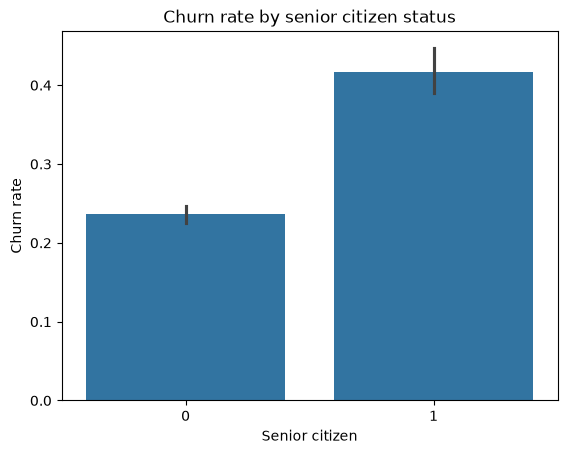

In [20]:
sns.barplot(
    data=telco_churn_df,
    x="senior_citizen",
    y=telco_churn_df["churn"].map({"Yes": 1, "No": 0})
)

plt.title("Churn rate by senior citizen status")
plt.ylabel("Churn rate")
plt.xlabel("Senior citizen")
plt.show()

Senior citizens appear to churn more.

### 4.3 Partner

In [21]:
pd.crosstab(
    telco_churn_df["partner"],
    telco_churn_df["churn"],
    normalize="index"
) * 100

churn,No,Yes
partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


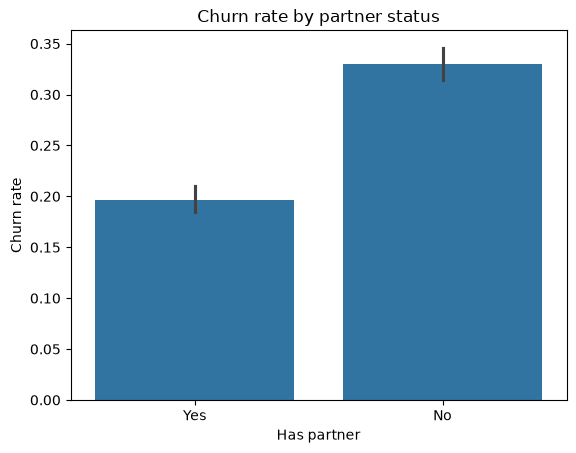

In [22]:
sns.barplot(
    data=telco_churn_df,
    x="partner",
    y=telco_churn_df["churn"].map({"Yes": 1, "No": 0})
)

plt.title("Churn rate by partner status")
plt.xlabel("Has partner")
plt.ylabel("Churn rate")
plt.show()

### 4.4 Dependents

In [23]:
#demographics: dependents
pd.crosstab(
    telco_churn_df["dependents"],
    telco_churn_df["churn"],
    normalize="index"
) * 100

churn,No,Yes
dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


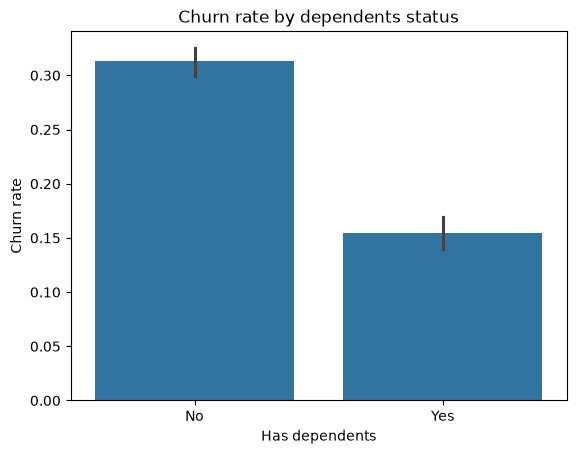

In [24]:
sns.barplot(
    data=telco_churn_df,
    x="dependents",
    y=telco_churn_df["churn"].map({"Yes": 1, "No": 0})
)

plt.title("Churn rate by dependents status")
plt.xlabel("Has dependents")
plt.ylabel("Churn rate")
plt.show()

## 5. Services 
### 5.1 Internet service

In [25]:
pd.crosstab(
    telco_churn_df["internet_service"],
    telco_churn_df["churn"],
    normalize="index"
) * 100

churn,No,Yes
internet_service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


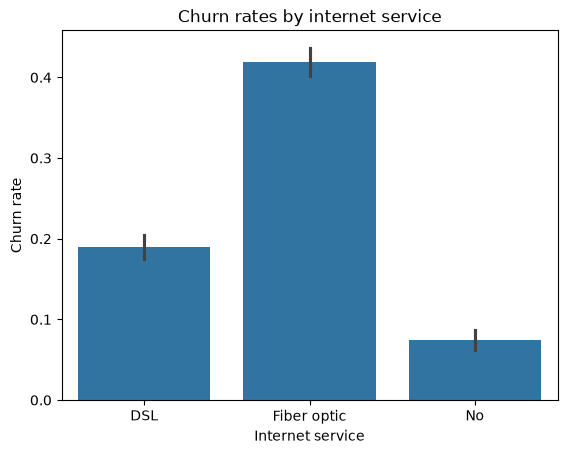

In [26]:
sns.barplot(
    data=telco_churn_df,
    x="internet_service",
    y=telco_churn_df["churn"].map({"Yes": 1, "No": 0})
)

plt.title("Churn rates by internet service")
plt.ylabel("Churn rate")
plt.xlabel("Internet service")
plt.show()

### 5.2 Phone service, online security, online backup, multiple_lines, device protection, tech support, streaming tv, streaming movies

In [27]:
service_cols = [
    "phone_service",
    "online_security",
    "online_backup",
    "multiple_lines",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

for col in service_cols:
    print(f"\n{col}")
    print(
        pd.crosstab(
            telco_churn_df[col],
            telco_churn_df["churn"],
            normalize="index"
        ) * 100
    )


phone_service
churn                 No        Yes
phone_service                      
No             75.073314  24.926686
Yes            73.290363  26.709637

online_security
churn                       No        Yes
online_security                          
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

online_backup
churn                       No        Yes
online_backup                            
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

multiple_lines
churn                    No        Yes
multiple_lines                        
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

device_protection
churn                       No        Yes
device_protection                        
No                   60.872375  39.127625
No internet service  92.595020   

## 6. Contract and billing
### 6.1 Contract type

In [28]:
pd.crosstab(
    telco_churn_df["contract"],
    telco_churn_df["churn"],
    normalize="index"
) * 100

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


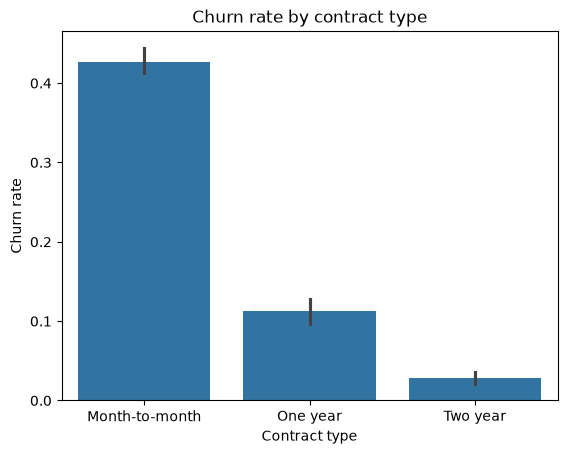

In [29]:
sns.barplot(
    data=telco_churn_df,
    x="contract",
    y=telco_churn_df["churn"].map({"Yes": 1, "No": 0})
)

plt.title("Churn rate by contract type")
plt.ylabel("Churn rate")
plt.xlabel("Contract type")
plt.show()

### 6.2 Payment method

In [30]:
pd.crosstab(
    telco_churn_df["payment_method"],
    telco_churn_df["churn"],
    normalize="index"
) * 100

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


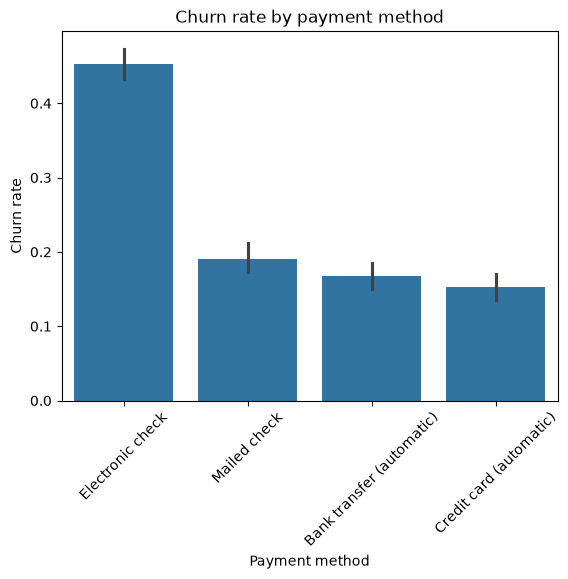

In [31]:
sns.barplot(
    data=telco_churn_df,
    x="payment_method",
    y=telco_churn_df["churn"].map({"Yes": 1, "No": 0} )
)

plt.title("Churn rate by payment method")
plt.ylabel("Churn rate")
plt.xlabel("Payment method")
plt.xticks(rotation=45)
plt.show()

### 6.3 Paperless billing

In [32]:
pd.crosstab(
    telco_churn_df["paperless_billing"],
    telco_churn_df["churn"],
    normalize="index"
) * 100

churn,No,Yes
paperless_billing,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [33]:
#summary table
categorical_analysis = [
    "gender",
    "senior_citizen",
    "partner",
    "dependents",
    "phone_service",
    "multiple_lines",
    "internet_service",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "contract",
    "paperless_billing",
    "payment_method"
]

for col in categorical_analysis:
    print(f"\n--- {col} ---")
    print(
        telco_churn_df.groupby(col)["churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
    )


--- gender ---
gender
Female    0.269209
Male      0.261603
Name: churn, dtype: float64

--- senior_citizen ---
senior_citizen
1    0.416813
0    0.236062
Name: churn, dtype: float64

--- partner ---
partner
No     0.329580
Yes    0.196649
Name: churn, dtype: float64

--- dependents ---
dependents
No     0.312791
Yes    0.154502
Name: churn, dtype: float64

--- phone_service ---
phone_service
Yes    0.267096
No     0.249267
Name: churn, dtype: float64

--- multiple_lines ---
multiple_lines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: churn, dtype: float64

--- internet_service ---
internet_service
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: churn, dtype: float64

--- online_security ---
online_security
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: churn, dtype: float64

--- online_backup ---
online_backup
No                     0.399288
Yes         

## 7. Customer segmentation

In [34]:
#tenure segmentation
telco_churn_df["tenure_group"] = pd.cut(
    telco_churn_df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [35]:
telco_churn_df.groupby("tenure_group")["churn"].apply(
    lambda x: (x == "Yes"). mean()
) * 100

tenure_group
0-6 months      52.937205
7-12 months     35.886525
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: churn, dtype: float64

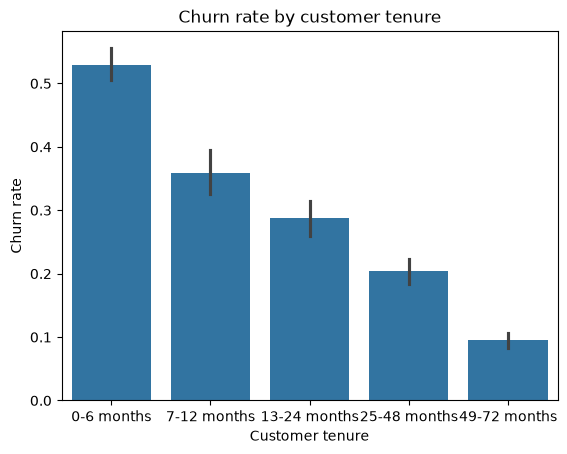

In [36]:
sns.barplot(
    data = telco_churn_df,
    x="tenure_group",
    y=telco_churn_df["churn"].map({"Yes": 1, "No": 0})
)

plt.title("Churn rate by customer tenure")
plt.xlabel("Customer tenure")
plt.ylabel("Churn rate")
plt.show()

The first 6-12 months represent the highest-risk period

### 7.1 Tenure x Contract type

In [37]:
tenure_contract = (
    telco_churn_df.groupby(
        ["tenure_group", "contract"],
        observed=True
    )
    .agg(
        customers = ("churn", "size"),
        churned = ("churn", lambda x: (x == "Yes").sum()),
        churn_rate = ("churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

tenure_contract.sort_values(
    "churn_rate",
    ascending = False
)

,tenure_group,contract,customers,churned,churn_rate
0,0-6 months,Month-to-month,1413,780,55.201699
3,7-12 months,Month-to-month,581,244,41.996558
6,13-24 months,Month-to-month,737,278,37.720488
9,25-48 months,Month-to-month,802,264,32.917706
12,49-72 months,Month-to-month,342,89,26.023392
13,49-72 months,One year,634,82,12.933754
10,25-48 months,One year,518,55,10.617761
4,7-12 months,One year,85,9,10.588235
1,0-6 months,One year,39,4,10.256410
7,13-24 months,One year,197,16,8.121827


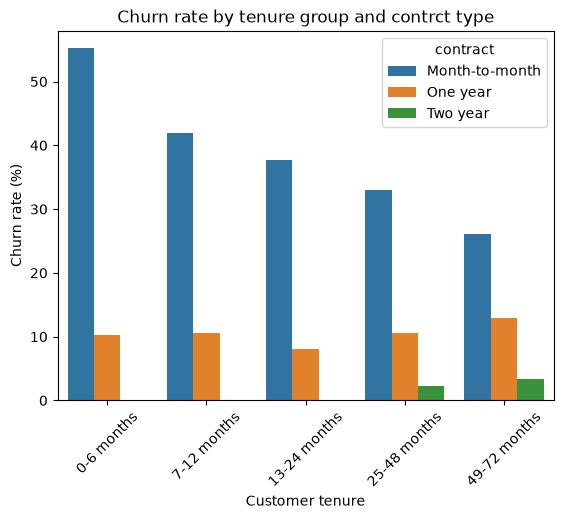

In [62]:
sns.barplot(
    data=tenure_contract,
    x="tenure_group",
    y="churn_rate",
    hue="contract"
)

plt.title("Churn rate by tenure group and contrct type")
plt.xlabel("Customer tenure")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=45)

plt.show()

New customers on month-to-month contracts represent a particularly high-risk segment.

### 7.2 Contract x Internet service

In [65]:
contract_internet = (
    telco_churn_df.groupby(
        ["contract", "internet_service"]
    )
    .agg(
        customers=("churn", "size"),
        churn_rate=("churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

contract_internet.sort_values(
    "churn_rate",
    ascending=False
)

,contract,internet_service,customers,churn_rate
1,Month-to-month,Fiber optic,2128,54.605263
0,Month-to-month,DSL,1223,32.215863
4,One year,Fiber optic,539,19.294991
2,Month-to-month,No,524,18.893130
3,One year,DSL,570,9.298246
7,Two year,Fiber optic,429,7.226107
5,One year,No,364,2.472527
6,Two year,DSL,628,1.910828
8,Two year,No,638,0.783699


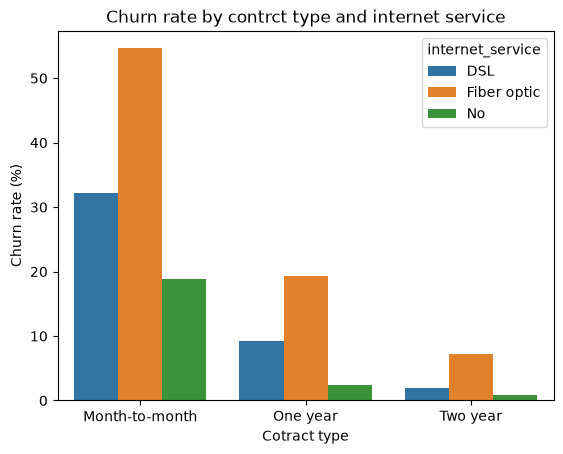

In [66]:
sns.barplot(
    data=contract_internet,
    x="contract",
    y="churn_rate",
    hue="internet_service"
)

plt.title("Churn rate by contrct type and internet service")
plt.xlabel("Cotract type")
plt.ylabel("Churn rate (%)")

plt.show()

### 7.3 Contract x Payment method

In [68]:
contract_payment = (
    telco_churn_df.groupby(
        ["contract", "payment_method"]
    )
    .agg(
        customers=("churn", "size"),
        churn_rate=("churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

contract_payment.sort_values(
    "churn_rate",
    ascending=False
)

,contract,payment_method,customers,churn_rate
2,Month-to-month,Electronic check,1850,53.729730
0,Month-to-month,Bank transfer (automatic),589,34.125637
1,Month-to-month,Credit card (automatic),543,32.780847
3,Month-to-month,Mailed check,893,31.578947
6,One year,Electronic check,347,18.443804
5,One year,Credit card (automatic),398,10.301508
4,One year,Bank transfer (automatic),391,9.718670
10,Two year,Electronic check,168,7.738095
7,One year,Mailed check,337,6.824926
8,Two year,Bank transfer (automatic),564,3.368794


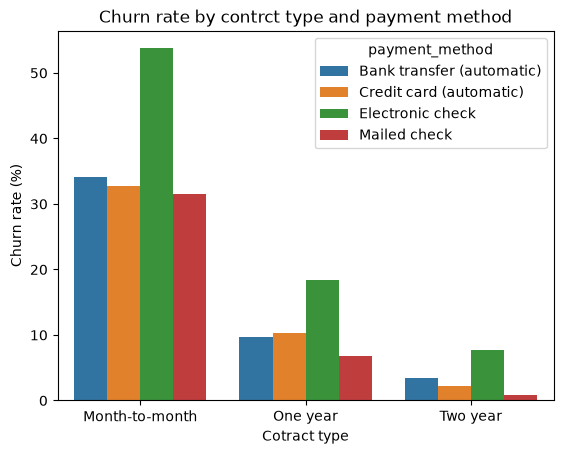

In [69]:
sns.barplot(
    data=contract_payment,
    x="contract",
    y="churn_rate",
    hue="payment_method"
)

plt.title("Churn rate by contrct type and payment method")
plt.xlabel("Cotract type")
plt.ylabel("Churn rate (%)")

plt.show()

### 7.4 Internet service x Tech support

In [40]:
internet_support = (
    telco_churn_df.groupby(
        ["internet_service", "tech_support"]
    )
    .agg(
        customers=("churn", "size"),
        churn_rate=("churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

internet_support

,internet_service,tech_support,customers,churn_rate
0,DSL,No,1243,27.755430
1,DSL,Yes,1178,9.677419
2,Fiber optic,No,2230,49.372197
3,Fiber optic,Yes,866,22.632794
4,No,No internet service,1526,7.404980


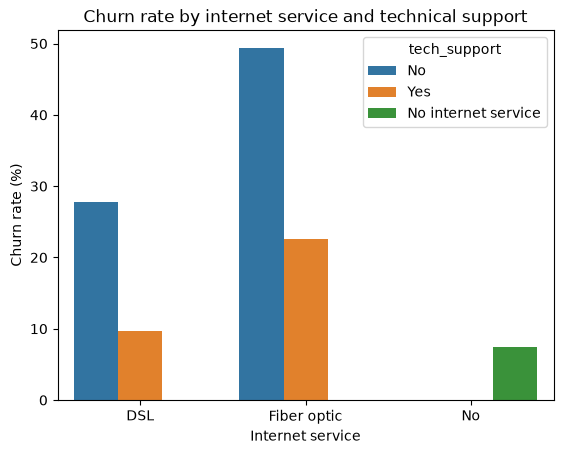

In [70]:
sns.barplot(
    data=internet_support,
    x="internet_service",
    y="churn_rate",
    hue="tech_support"
)

plt.title("Churn rate by internet service and technical support")
plt.xlabel("Internet service")
plt.ylabel("Churn rate (%)")

plt.show()

### 7.5 Internet service x Online security

In [41]:
internet_security = (
    telco_churn_df.groupby(
        ["internet_service", "online_security"]
    )
    .agg(
        customers=("churn", "size"),
        churn_rate=("churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

internet_security

,internet_service,online_security,customers,churn_rate
0,DSL,No,1241,27.961322
1,DSL,Yes,1180,9.491525
2,Fiber optic,No,2257,49.357554
3,Fiber optic,Yes,839,21.811681
4,No,No internet service,1526,7.404980


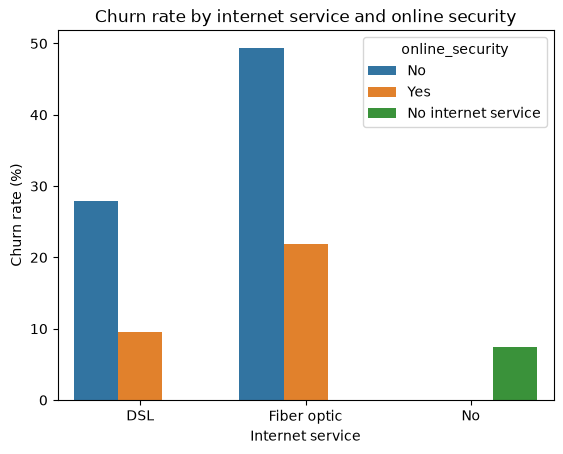

In [71]:
sns.barplot(
    data=internet_security,
    x="internet_service",
    y="churn_rate",
    hue="online_security"
)

plt.title("Churn rate by internet service and online security")
plt.xlabel("Internet service")
plt.ylabel("Churn rate (%)")

plt.show()

### 7.6 Monthly charges x Tenure

In [43]:
#creating 4 categories for the monthly charges
telco_churn_df["monthly_charge_group"] = pd.qcut(
    telco_churn_df["monthly_charges"],
    q=4,
    labels=[
        "Low",
        "Medium-low",
        "Medium-high",
        "High"
    ]
)

In [45]:
charge_tenure = (
    telco_churn_df.groupby(
        ["tenure_group", "monthly_charge_group"],
        observed=True
    )
    .agg(
        customers=("churn", "size"),
        churn_rate=("churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)
charge_tenure

,tenure_group,monthly_charge_group,customers,churn_rate
0,0-6 months,Low,451,29.490022
1,0-6 months,Medium-low,501,52.495010
2,0-6 months,Medium-high,409,72.127139
3,0-6 months,High,120,77.500000
4,7-12 months,Low,201,12.935323
5,7-12 months,Medium-low,203,21.674877
6,7-12 months,Medium-high,201,54.228856
7,7-12 months,High,100,74.000000
8,13-24 months,Low,276,5.797101
9,13-24 months,Medium-low,276,22.101449


Text(0, 0.5, 'Monthly charges')

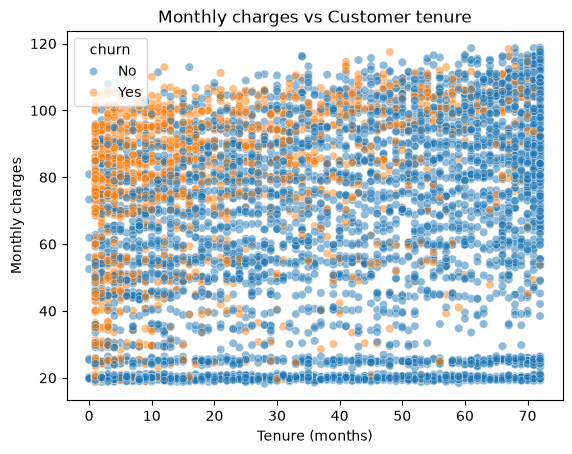

In [60]:
sns.scatterplot(
    data=telco_churn_df,
    x="tenure",
    y="monthly_charges",
    hue="churn",
    alpha=0.5
)

plt.title("Monthly charges vs Customer tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly charges")

High-charge new customers are especially vulnerable to churn.

## 8. Customer engagement

In [46]:
telco_churn_df["service_count"] = (
    (telco_churn_df["phone_service"] == "Yes").astype(int)
    + (telco_churn_df["multiple_lines"] == "Yes").astype(int)
    + (telco_churn_df["online_security"] == "Yes").astype(int)
    + (telco_churn_df["online_backup"] == "Yes").astype(int)
    + (telco_churn_df["device_protection"] == "Yes").astype(int)
    + (telco_churn_df["tech_support"] == "Yes").astype(int)
    + (telco_churn_df["streaming_tv"] == "Yes").astype(int)
    + (telco_churn_df["streaming_movies"] == "Yes").astype(int)
)

In [47]:
service_count_churn = (
    telco_churn_df.groupby("service_count")
    .agg(
        customers=("churn", "size"),
        churn_rate=("churn", lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

service_count_churn

,service_count,customers,churn_rate
0,0,80,43.750000
1,1,1701,21.105232
2,2,1188,32.828283
3,3,965,36.476684
4,4,922,31.344902
5,5,908,25.550661
6,6,676,22.485207
7,7,395,12.405063
8,8,208,5.288462


## 9. Summary

In [55]:
categorical_cols = [
    "gender",
    "senior_citizen",
    "partner",
    "dependents",
    "phone_service",
    "multiple_lines",
    "internet_service",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "contract",
    "paperless_billing",
    "payment_method"
]

In [57]:
summary_list = []

for col in categorical_cols:
    temp = (
        telco_churn_df.groupby(col)
        .agg(
            customers=("churn", "size"),
            churned=("churn", lambda x: (x == "Yes").sum()),
            churn_rate=("churn", lambda x: (x == "Yes").mean() * 100)
        )
        .reset_index()
    )

    temp.insert(0, "variable", col)
    temp = temp.rename(columns={col: "category"})

    summary_list.append(temp)

eda_summary = pd.concat(
    summary_list,
    ignore_index=True
)

eda_summary["churn_rate"] = (
    eda_summary["churn_rate"].round(1)
)

eda_summary

,variable,category,customers,churned,churn_rate
0,gender,Female,3488,939,26.9
1,gender,Male,3555,930,26.2
2,senior_citizen,0,5901,1393,23.6
3,senior_citizen,1,1142,476,41.7
4,partner,No,3641,1200,33.0
5,partner,Yes,3402,669,19.7
6,dependents,No,4933,1543,31.3
7,dependents,Yes,2110,326,15.5
8,phone_service,No,682,170,24.9
9,phone_service,Yes,6361,1699,26.7


In [58]:
eda_summary.sort_values(
    "churn_rate",
    ascending=False
).head(15)

,variable,category,customers,churned,churn_rate
41,payment_method,Electronic check,2365,1071,45.3
34,contract,Month-to-month,3875,1655,42.7
14,internet_service,Fiber optic,3096,1297,41.9
16,online_security,No,3498,1461,41.8
3,senior_citizen,1,1142,476,41.7
25,tech_support,No,3473,1446,41.6
19,online_backup,No,3088,1233,39.9
22,device_protection,No,3095,1211,39.1
31,streaming_movies,No,2785,938,33.7
38,paperless_billing,Yes,4171,1400,33.6


## 10. Key findings

| Finding | Evidence | Interpretation | Business implication |
| --- | --- | --- | --- |
| 1. Churn is concentrated among new customers | Customers with 0-6 months of tenure had a 52.9% churn rate, compared with only 9.5% among customers with 49-72 months of tenure. Churn declined consistently as tenured increased. | The early stages of the customer relationship appear to represent the highest-risk period for attrition. | Retention efforts should place particular emphasis on onboarding and the first several months of the customer lifecycle.
| 2. Month-to-month contracts are strongly associated with churn | Month-to-month customers has a 42.7% churn rate, compared with 11.3% for one-year contracts and 2.8% for two-year contracts. | Customers with less contractual commitment are more likely to leave. | The company could test incentives that encourage suitable high-risk customers to transition to longer-term contracts. |
| 3. New month-to-month customers form a particularly high-risk segment | Among customers with 0-6 months of tenure and month-to-month contracts, churn reached 55.2%. This segment contained 1,413 customers, of whom 780 churned. | Short tenure and flexible contracts appear to form a particularly high-risk segment. | This segment should be considered a priority group for early retention interventions and targeted contract offers. |
| 4. Fiber optic customers show elevated churn | Fiber optic customers had a 41.9% churn rate, compared with 19.0% for DSL customers and 7.4% for customers without internet service. | Fiber-optic customers appear to represent a higher-risk customer group. | The company should investigate the cutomer experience of the fiber optic offering. |
| 5. Fiber optic customers on month-to-month contracts are especially vulnerable | Customers combining fiber optic internet and month-to-month contracts had a 54.6% churn rate, representing 1,162 churned customers out of 2,128 in the segment. | The churn associated with fiber optic service is concentrated among customers with flexible contracts. | Retention strategies for fiber customers should account for contract type. |
| 6. Technical support is associated with lower churn among internet customers. | Overall, customers without technical support had a 41.6% churn rate, compared with 15.2% among customers with technical support. Among fiber customers specifically, churn was 49.4% without technical support vs. 22.6% with technical support. | Customers with technical support services show stronger retention. | The company could investigate whether proactive support or access to technical assistance can increase retention among high-risk customers. |
| 7. Online security shows a similar relationship with retention | Customers without online security had a 41.8% churn rate, compared with 14.6% among customers with online security. | Adoprtion of online security is associated with lower cchurn and may reflect greater engagement. | Security services could be investigated as part of retention-oriented service offers. |
| 8. Elelctronic check customers show unusually high churn. | Customers paying by electoric check had a 45.3% churn rate, compared with 19.1% for mailed checks, 16.7% for automatic bank transfers, and 15.2% for automatic credit cards. | Payment method is strongly associated with churn. | The company could investigate the characteristic of electronic-check customers and whether automatic-payment adoption could be encouraged. |
| 9. Month-to-month electronic-check customers represent another major risk segment. | Customers combining a month-to-month contract with electronic check payment had a 53.7% churn rate. | The combination of flexible contracts and electronic check payment appears to be the highest risk segment. | This group could be prioritized for targeted retention testing, including payment method incentives and longer-term contract offers. |
| 10. Higher monthly charges are associated with churn | Customers who churned had average monthly charges of approximately $74.44, compared with $61.27 among customers who remained. | Higher monthly cost may contribute to differences in perceived value, but monthly charges are also related to service type and broduct bundles. | Priicng and perceived value should be investigated jointly with internet service, contract type, and subscribed services. |
| 11. Some demographic characteristics show differences, bu they are less actionable | Senior citizens had a 41.7% churn rate versus 23.6% among non-senior customers. Customers without partners had 33.0% churn versus 19.7% with partners, while customers without dependents had 31.3% churn versus 15.5% with dependents. | Some demographics and household variables identify groups with different observed churn. These variables may also be related to tenure, services and account characteristics. | Demographic attributes may help with risk segmentation but should not automatically determine retention actions. |

The EDA suggests that churn is not driven by a single customer characteristic. Instead, churn risk appears to be concentrated among combinations of customer lifecycle, contract, service, and billing.

The clearest high-risk profile is a customer who is relatively new, on a month-to-month contract, uses fiber optic internet and electronic check payment option.

Conversely, longer tenure, longer-term contracts, and adoption of services such as technical support and online security are associated with lower churn rates.